### Libraries

In [97]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

### Loading dataset

In [98]:
players = pd.read_csv('player datasets/players_22.csv',low_memory=False)

In [99]:
players

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


### lets specify we are gonna cluster the players

In [100]:
features = ['overall','potential','wage_eur','value_eur','age']

In [101]:
players = players.dropna(subset=features)

In [102]:
data = players[features].copy()

In [103]:
data

,overall,potential,wage_eur,value_eur,age
0,93,93,320000.0,78000000.0,34
1,92,92,270000.0,119500000.0,32
2,91,91,270000.0,45000000.0,36
3,91,91,270000.0,129000000.0,29
4,91,91,350000.0,125500000.0,30
...,...,...,...,...,...
19234,47,52,1000.0,70000.0,22
19235,47,59,500.0,110000.0,19
19236,47,55,500.0,100000.0,21
19237,47,60,500.0,110000.0,19


###  we are gonna do the ff from scratch

#### 1, sclaing
#### 2, intailize random centroid
#### 3, label each data point
#### 4, update centroid


##### scaling our data into range of 1 to 10

In [104]:
data = ((data-data.min())/(data.max()-data.min()))*9+1

In [105]:
data.describe()

,overall,potential,wage_eur,value_eur,age
count,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000
mean,4.670472,5.319998,1.219443,1.131826,4.063345
std,1.346635,1.191076,0.501528,0.353229,1.575838
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.739130,4.521739,1.012876,1.021620,2.666667
50%,4.717391,5.304348,1.064378,1.044817,4.000000
75%,5.500000,6.086957,1.193133,1.092370,5.333333
max,10.000000,10.000000,10.000000,10.000000,10.000000


In [106]:
data.head()

,overall,potential,wage_eur,value_eur,age
0,10.000000,9.608696,9.227468,4.618307,7.000000
1,9.804348,9.413043,7.939914,6.543654,6.333333
2,9.608696,9.217391,7.939914,3.087308,7.666667
3,9.608696,9.217391,7.939914,6.984396,5.333333
4,9.608696,9.217391,10.000000,6.822018,5.666667


#### intailize a centroid

In [107]:
## picking a sample centroid from each column or feature
def random_centroids(data , k):
    centroids =[]
    for i in range(k):   
        centroid = data.apply(lambda x: float(x.sample().iloc[0]))
        centroids.append(centroid)
    return pd.concat(centroids, axis=1)

In [108]:

centroids = random_centroids(data,5)
centroids

,0,1,2,3,4
overall,3.934783,2.173913,4.326087,7.065217,3.934783
potential,4.326087,3.934783,6.673913,6.869565,4.326087
wage_eur,1.000000,1.012876,1.244635,1.193133,1.011588
value_eur,1.741885,1.092370,1.019300,1.138764,1.110928
age,6.333333,3.000000,6.666667,7.000000,3.000000


#### compute the distanc between each data point to the centroid we intailize

In [109]:
distance =centroids.apply(lambda x : np.sqrt(((data-x)**2).sum(axis=1)))
# this displayes the distance of all data points to the centroids
distance

,0,1,2,3,4
0,11.878649,13.760548,10.844161,9.631902,12.668670
1,11.469452,13.305876,10.628760,9.441846,12.204763
2,10.385976,12.526906,9.191227,7.857601,11.393143
3,11.522347,13.089164,10.796395,9.718530,12.002580
4,12.781641,14.279017,12.070757,11.118436,13.290499
...,...,...,...,...,...
19234,5.270034,2.626476,7.102000,8.985755,4.015902
19235,5.459844,1.828366,6.835180,8.783738,3.391177
19236,5.218562,2.144244,6.882799,8.813013,3.656150
19237,5.414080,1.731590,6.730775,8.698341,3.316993


In [110]:
# get cluster label
def get_labels(data,centroids):
    distance =centroids.apply(lambda x : np.sqrt(((data-x)**2).sum(axis=1)))
    return distance.idxmin(axis=1)

In [111]:
labels = cluster_labels(data,centroids)
labels.value_counts()

4    9901
0    3762
3    2879
1    1884
2     739
Name: count, dtype: int64

### geometric mean
why we use exp and log is the sum is too huge and it takes a lot of memory thus way is we are using the exponential and logarthimic functions

In [112]:
data.groupby(labels).apply(lambda x:np.exp(np.log(x).mean()))

,overall,potential,wage_eur,value_eur,age
0,4.577289,4.200165,1.075929,1.030443,5.860276
1,2.240014,4.047965,1.014352,1.009920,2.379902
2,5.742693,5.473430,1.272387,1.078865,5.570207
3,6.719819,6.608344,1.751423,1.464329,5.038558
4,4.373315,5.454486,1.096274,1.067031,3.072419


##### this is the geometric mean of the features for each player

#### updating the centroids

In [113]:
def new_centroids(data, labels,k):
    return data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T

In [114]:
from sklearn.decomposition import PCA
from IPython.display import clear_output

In [115]:
def plot_clusters(data,labels,centroids,iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    clear_output(wait=True)
    plt.title(f'Iteration{ iteration}')
    plt.scatter(x=data_2d[:,0],y=data_2d[:,1],c=labels)
    plt.scatter(x=centroids_2d[:,0],y=centroids_2d[:,1])
    plt.show()

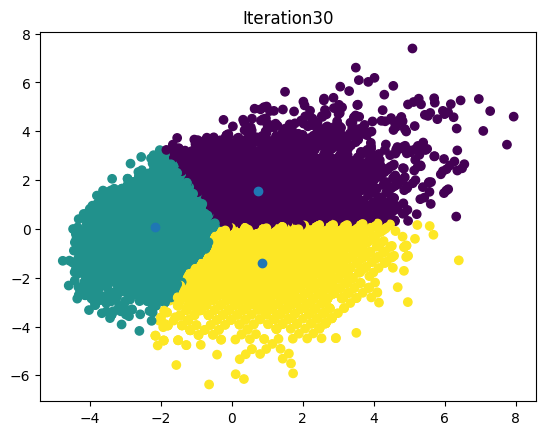

In [116]:
max_iterations = 100
k=3
centroids = random_centroids(data,k)
old_centroids = pd.DataFrame()
iteration =1
while iteration<max_iterations and not centroids.equals(old_centroids):
    old_centroids=centroids
    labels = get_labels(data,centroids)
    centroids = new_centroids(data,labels,k)
    plot_clusters(data,labels,centroids,iteration)
    iteration+=1

In [117]:
centroids

,0,1,2
overall,5.806043,3.206838,4.784633
potential,6.497993,4.928473,4.506962
wage_eur,1.420001,1.028505,1.118904
value_eur,1.285501,1.026614,1.044980
age,3.596161,2.518708,5.472247


In [118]:
players[labels==2][['short_name']+features]

,short_name,overall,potential,wage_eur,value_eur,age
199,Pepe,82,82,14000.0,5500000.0,38
284,Joaquín,81,81,23000.0,8500000.0,39
292,José Fonte,81,81,30000.0,4600000.0,37
388,G. Buffon,80,80,18000.0,2300000.0,43
509,Iniesta,79,79,10000.0,5500000.0,37
...,...,...,...,...,...,...
18890,S. Haokip,51,51,500.0,60000.0,28
18971,Lalkhawpuimawia,51,51,500.0,60000.0,29
19032,Song Yue,50,50,2000.0,40000.0,29
19100,J. Russell,49,49,500.0,15000.0,36


#### lets compire the sickit learn algorithm

In [119]:
from sklearn.cluster import KMeans 
kmeans = KMeans(3)
kmeans.fit(data)


KMeans(n_clusters=3)

In [120]:
centroids = kmeans.cluster_centers_


In [121]:
pd.DataFrame(centroids ,columns=features).T

,0,1,2
overall,3.602247,6.234851,4.800409
potential,5.208414,6.623743,4.503433
wage_eur,1.040100,1.658628,1.112740
value_eur,1.035908,1.414491,1.039977
age,2.712566,4.144340,5.608753
